# Download the data

In [199]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

DATA_DIR = Path("data")
if not DATA_DIR.exists():
    DATA_DIR = Path("ch02_end_to_end/data")

In [200]:
# Valid NA columns based on data_description.txt
documented_none_cols = [
    "Alley",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond", "GarageYrBlt",
    "PoolQC",
    "Fence",
    "MiscFeature",
]

raw = pd.read_csv(DATA_DIR / "train.csv", keep_default_na=False)

# Figure out columns with actual missing values
literal_na_counts = (raw == "NA").sum()
literal_na_cols = set(literal_na_counts[literal_na_counts > 0].index)
true_missing_candidates = sorted(literal_na_cols - set(documented_none_cols))
true_missing_candidates

['Electrical', 'LotFrontage', 'MasVnrArea', 'MasVnrType']

In [201]:
# Categorize the NA columns.
DOCUMENTED_NONE_TEXT_COLS = [
    "Alley",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature",
]

# With this attribute NA just means garage does not exist, similar to GarageType etc.
DOCUMENTED_NONE_NUMERIC_COLS = ["GarageYrBlt"]

# These are columns where missing values are actually unkowns.
TRUE_MISSING_NUMERIC_COLS = [
    "LotFrontage",
    "MasVnrArea",
]

TRUE_MISSING_CATEGORICAL_COLS = [
    "MasVnrType",
    "Electrical",
]


In [202]:
# Helper function to clear up valid NA values from missing ones.
def clean_na_values(df):
  # In these columns NA means that the feature does not exist
  # eg. no alley, no basement etc -> actual valid values.
  df[DOCUMENTED_NONE_TEXT_COLS] = df[DOCUMENTED_NONE_TEXT_COLS].replace("NA", "None")

  # Handle valid numeric NAs. We convert the value to numeric and fall back to YearBuilt for the missing values.
  for col in DOCUMENTED_NONE_NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col].replace("NA", np.nan))
  df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])

  # In these the value is actually missing
  true_missing_cols = TRUE_MISSING_NUMERIC_COLS + TRUE_MISSING_CATEGORICAL_COLS
  df[true_missing_cols] = df[true_missing_cols].replace("NA", np.nan)
  
  # Convert numeric columns that were read as strings because they contained "NA" (for pipeline validation)
  for col in TRUE_MISSING_NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col])

  return df

# Loads the ames housing dataset
def load_housing_data():
  csv_path = DATA_DIR / "train.csv"
  if not csv_path.is_file():
    raise FileNotFoundError(csv_path) 

  df = pd.read_csv(csv_path, keep_default_na=False)
  df = clean_na_values(df) 

  return df

# Get an outlook on the dataset

In [203]:
housing_full = load_housing_data()
housing_full.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000


In [204]:
# Drop the Id column since its not needed
housing_full = housing_full.drop("Id", axis=1)

housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          1460 non-null   str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [205]:
housing_full.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1976.507534,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,26.306739,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1872.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1959.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1978.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


SalePrice looks to be right skewed due to some outliers in the dataset.

In [206]:
housing_full["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

# Create a test set

<Axes: >

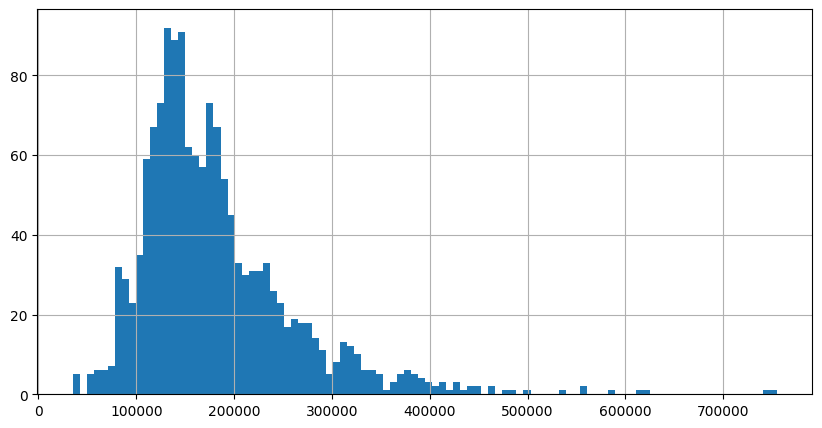

In [207]:
# Check the distribution of the SalePrice feature.
housing_full["SalePrice"].hist(figsize=(10,5), bins=100)

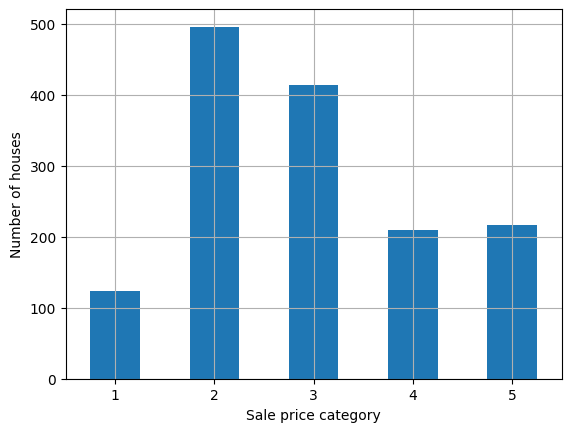

In [208]:
# Divide the SalePrice feature into five categories, so that we can stratify the train/test split.
housing_full["SalePrice_cat"] = pd.cut(
  housing_full["SalePrice"],
  bins=[0, 100000, 150000, 200000, 250000, np.inf],
  labels=[1, 2, 3, 4, 5]                                 
) 

cat_counts = housing_full["SalePrice_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Sale price category")
plt.ylabel("Number of houses")
plt.show()

In [209]:
# Do a stratified train/test split to guarantee that both have similar proportions as the full dataset.
strat_train_set, strat_test_set = train_test_split(
  housing_full, test_size=0.2, stratify=housing_full["SalePrice_cat"], random_state=42
)

In [210]:
# Check the category distributions on the test set.
strat_test_set["SalePrice_cat"].value_counts() / len(strat_test_set)

SalePrice_cat
2    0.339041
3    0.284247
5    0.147260
4    0.143836
1    0.085616
Name: count, dtype: float64

In [211]:
# Drop the cat column as its not needed anymore.
housing_full = housing_full.drop(columns="SalePrice_cat")
for set_ in (strat_train_set, strat_test_set):
  set_.drop("SalePrice_cat", axis=1, inplace=True)

In [212]:
# The stratified set based on binned SalePrice was nice, but OverallQual seems like a 
# more natural fit. Its binned from 1 to 10 out of the box, and correlates strongly with SalePrice
# that we are trying to predict.
strat_train_set, strat_test_set = train_test_split(
  housing_full, test_size=0.2, stratify=housing_full["OverallQual"], random_state=42
)

strat_test_set["OverallQual"].value_counts() / len(strat_test_set)

OverallQual
5     0.270548
6     0.256849
7     0.219178
8     0.113014
4     0.078767
9     0.030822
3     0.013699
10    0.013699
2     0.003425
Name: count, dtype: float64

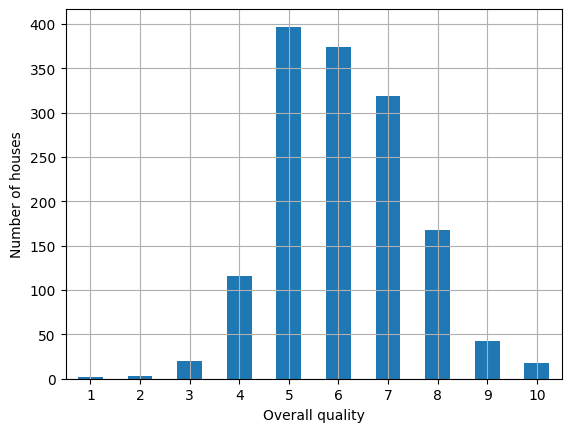

In [213]:
qual_counts = housing_full["OverallQual"].value_counts().sort_index()
qual_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Overall quality")
plt.ylabel("Number of houses")
plt.show()

# Visualize the data

<Axes: >

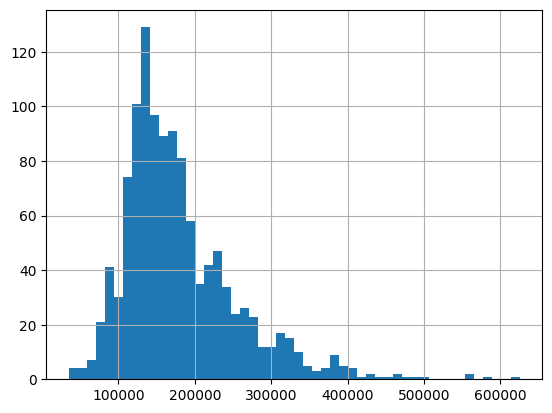

In [214]:
housing_copy = strat_train_set.copy()

housing_copy['SalePrice'].hist(bins=50)

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

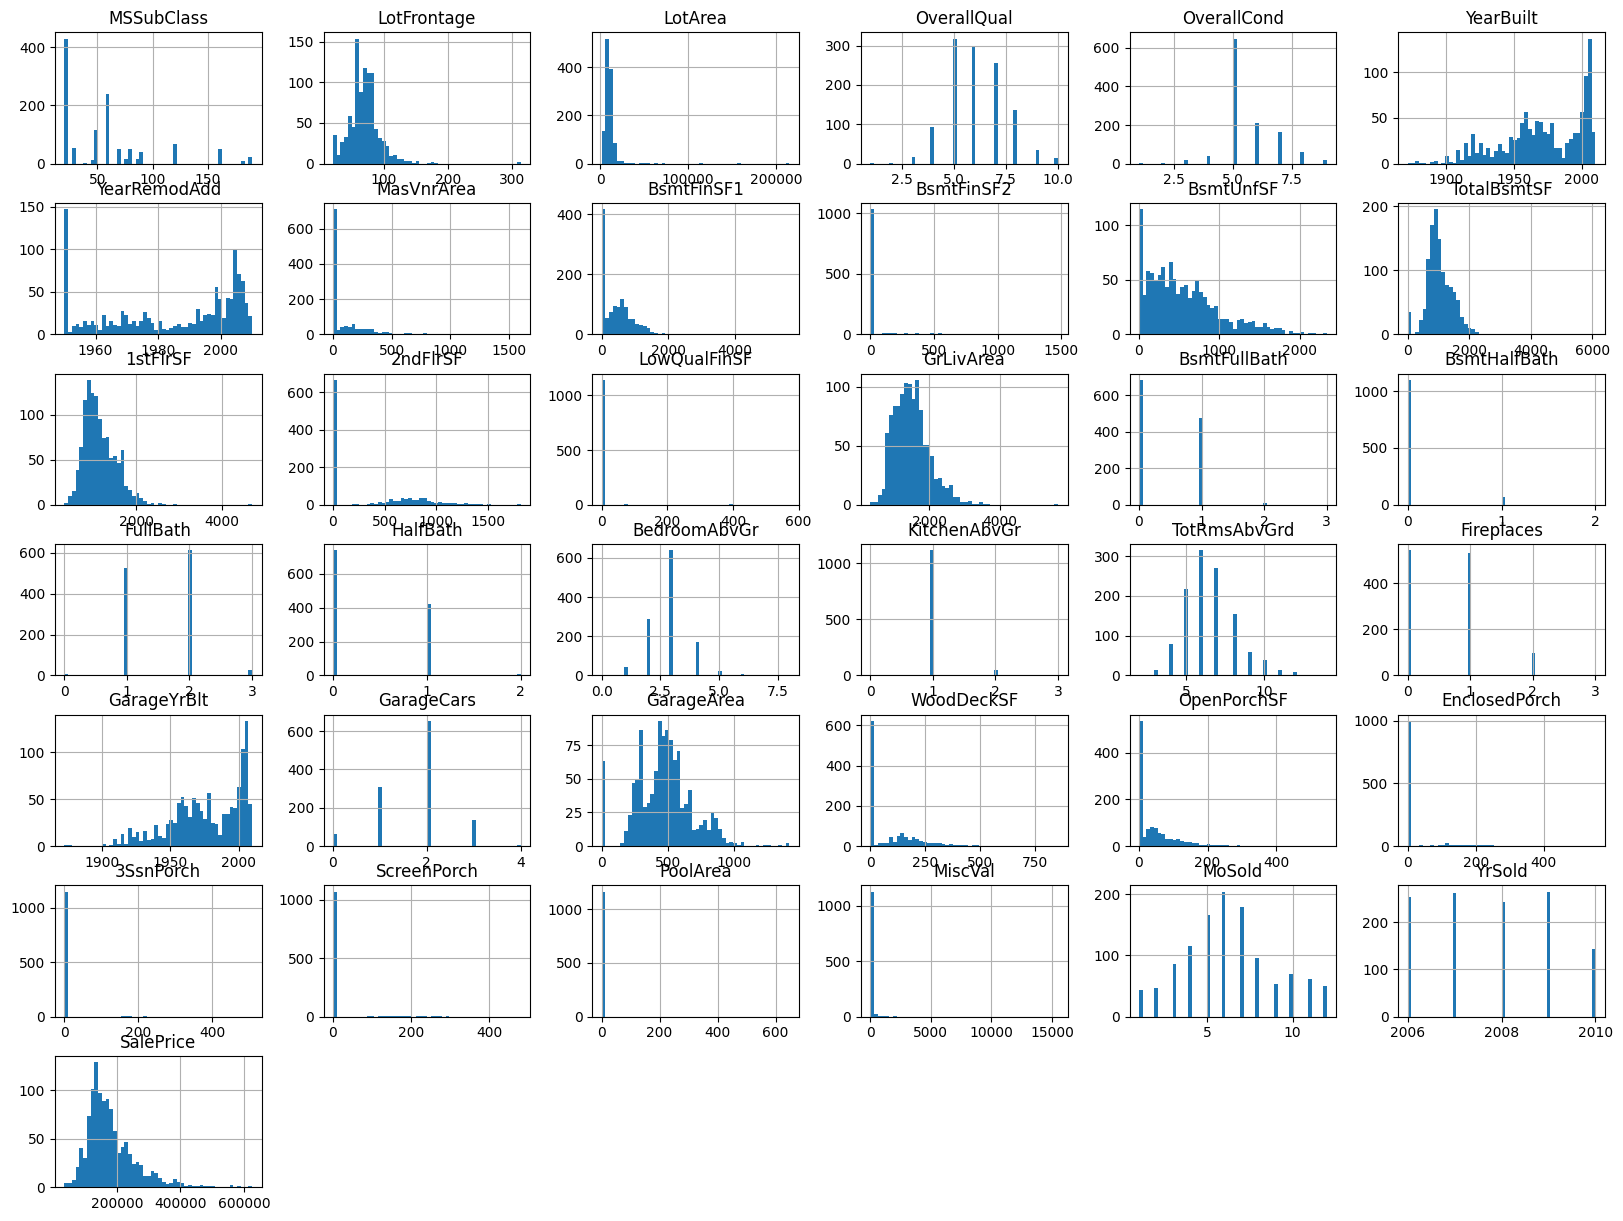

In [215]:
housing_copy.hist(figsize=(20,15), bins=50)

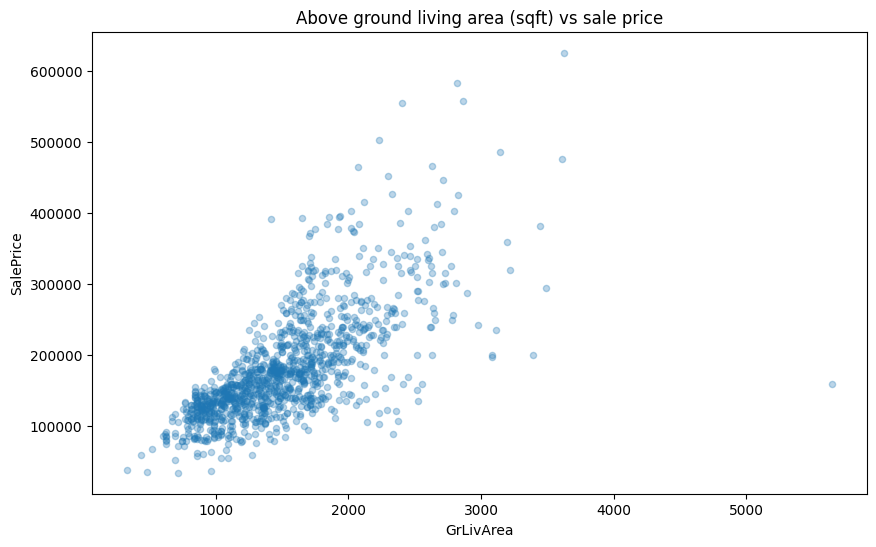

In [216]:
housing_copy.plot(
  kind="scatter", x="GrLivArea", y="SalePrice",
  alpha=0.3, figsize=(10,6)
)
plt.title("Above ground living area (sqft) vs sale price")
plt.show()

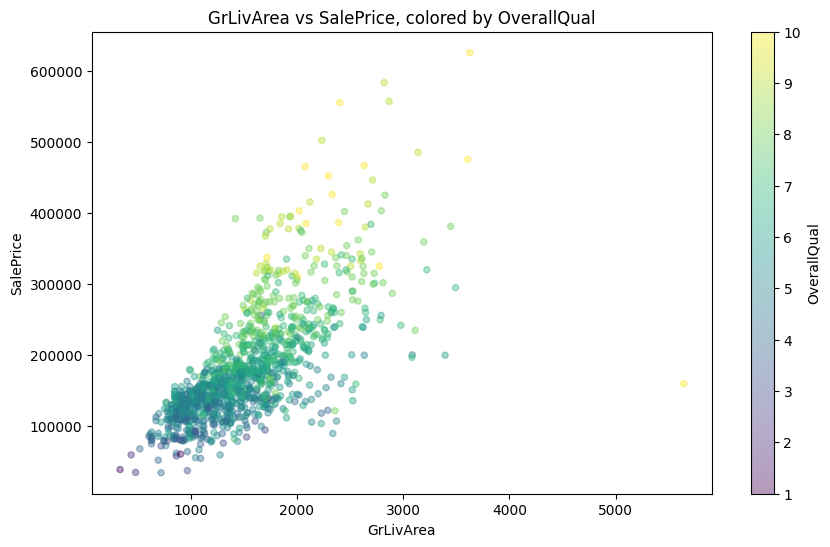

In [217]:
housing_copy.plot(
    kind="scatter", x="GrLivArea", y="SalePrice",
    alpha=0.4, c="OverallQual", cmap="viridis",
    figsize=(10, 6), colorbar=True,
)
plt.title("GrLivArea vs SalePrice, colored by OverallQual")
plt.show()

# Correlations

In [218]:
corr_matrix = housing_copy.corr(numeric_only=True)

In [219]:
corr_matrix["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.800531
GrLivArea        0.700908
GarageCars       0.651388
GarageArea       0.634647
TotalBsmtSF      0.604969
1stFlrSF         0.596394
FullBath         0.563145
TotRmsAbvGrd     0.534714
YearBuilt        0.528381
YearRemodAdd     0.526142
GarageYrBlt      0.515230
Fireplaces       0.462406
MasVnrArea       0.461716
LotFrontage      0.353105
BsmtFinSF1       0.351111
OpenPorchSF      0.325071
WoodDeckSF       0.312707
2ndFlrSF         0.307961
HalfBath         0.290130
LotArea          0.275339
BsmtUnfSF        0.242704
BsmtFullBath     0.231159
BedroomAbvGr     0.175717
ScreenPorch      0.127168
MoSold           0.083639
3SsnPorch        0.056172
PoolArea         0.015600
BsmtFinSF2      -0.003980
YrSold          -0.005636
MiscVal         -0.024854
LowQualFinSF    -0.030394
BsmtHalfBath    -0.040339
OverallCond     -0.081920
MSSubClass      -0.087740
EnclosedPorch   -0.130961
KitchenAbvGr    -0.137589
Name: SalePrice, dtype: float64

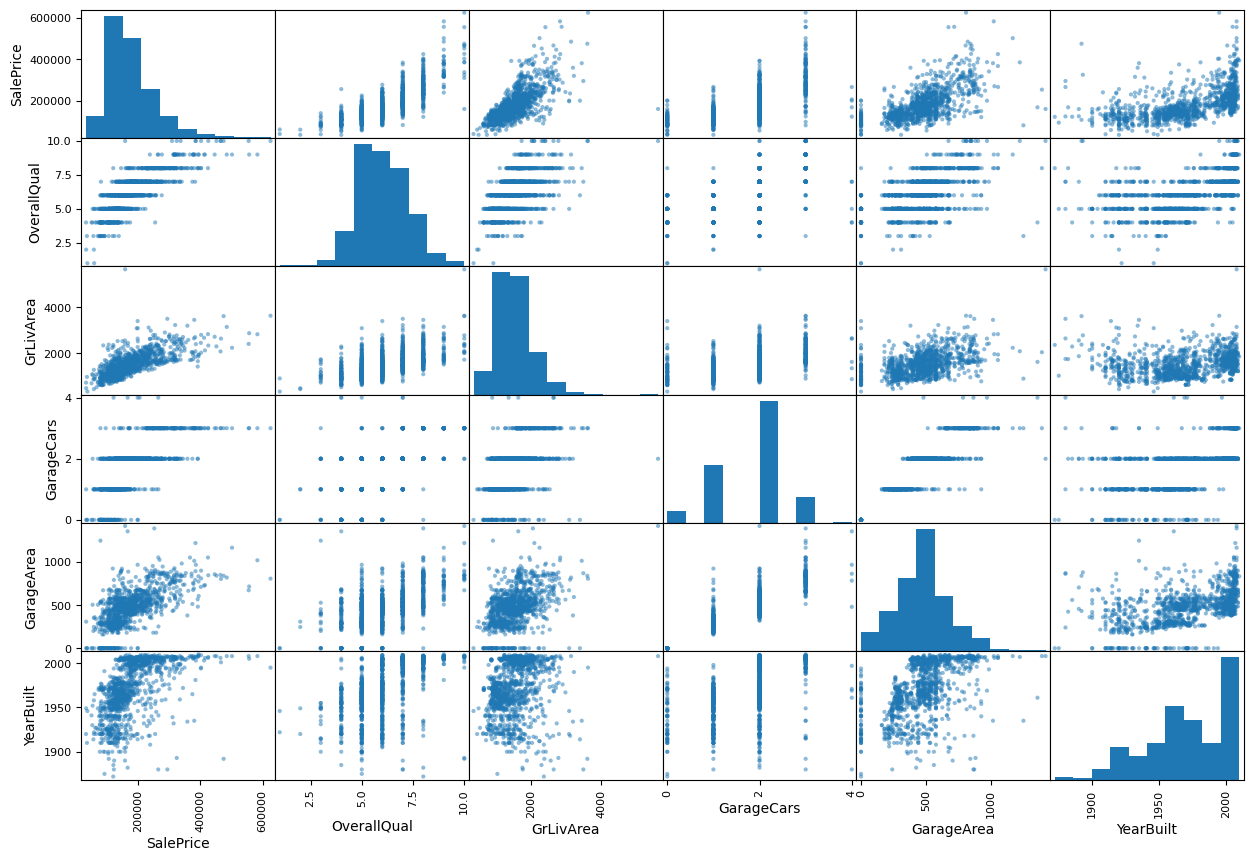

In [220]:
from pandas.plotting import scatter_matrix

attributes = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "YearBuilt"]
scatter_matrix(housing_copy[attributes], figsize=(15,10))

plt.show()

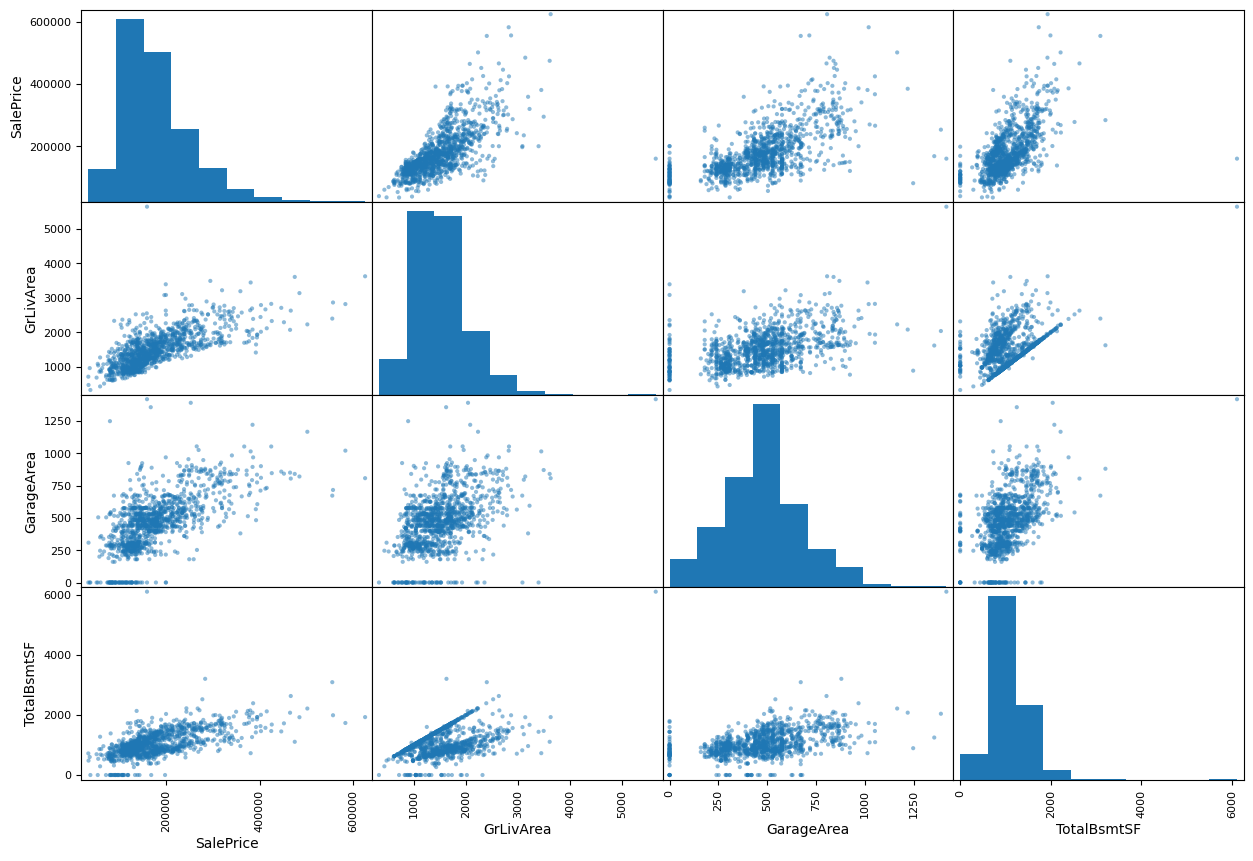

In [221]:
attributes = ["SalePrice", "GrLivArea", "GarageArea", "TotalBsmtSF"]
scatter_matrix(housing_copy[attributes], figsize=(15,10))

plt.show()

In [222]:
housing_copy.groupby("Neighborhood")["LotFrontage"].agg(
    ["median", "mean", "std", "count"]
).sort_values("median")

,median,mean,std,count
Neighborhood,,,,
BrDale,21.0,21.500000,1.167748,12
MeadowV,21.0,28.285714,10.306298,14
Blueste,24.0,24.000000,0.000000,2
NPkVill,24.0,32.285714,14.150551,7
Veenker,38.0,49.600000,22.864820,5
Blmngtn,43.0,47.222222,5.044249,9
BrkSide,52.0,55.897436,10.233574,39
IDOTRR,60.0,63.758621,19.177098,29
SWISU,60.0,60.111111,11.570189,18


# Clean the data

#### Handling empty values

In [223]:
# While loading the dataset we already cleaned the NA values. 
# Valid NAs are "None" and actual missing values are NaN.
# Check how many have and for which features.
missing = housing_copy.isna().sum()
missing[TRUE_MISSING_CATEGORICAL_COLS + TRUE_MISSING_NUMERIC_COLS].sort_values(ascending=False)

LotFrontage    206
MasVnrType       8
MasVnrArea       8
Electrical       1
dtype: int64

In [224]:
# Are the same rows missing both MasVnrType and MasVnrArea?
housing_copy[housing_copy["MasVnrArea"].isna()][["MasVnrType", "MasVnrArea"]]


,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
973,NaN,NaN
936,NaN,NaN
1278,NaN,NaN
1243,NaN,NaN
650,NaN,NaN
977,NaN,NaN


In [225]:
# Fill missing MasVnrArea with 0 based on the pattern in the training data where missing MasVnrType = missing MasVnrArea
# This is a tradeoff for simplicity, as real data might have cases where one value is present and the other is not.
housing_copy["MasVnrArea"] = housing_copy["MasVnrArea"].fillna(0)
housing_copy["MasVnrType"] = housing_copy["MasVnrType"].fillna("None")

In [226]:
from sklearn.impute import SimpleImputer

# Handle missing numeric values with the median value.
num_imputer = SimpleImputer(strategy="median")

# Fit the imputer to the (numeric) train data set
housing_num = housing_copy.select_dtypes(include=[np.number])
num_imputer.fit(housing_num)

# Use the trained imputer to replace empty values with the learned median.
X = num_imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [227]:
num_imputer.statistics_

array([5.0000e+01, 7.0000e+01, 9.5040e+03, 6.0000e+00, 5.0000e+00,
       1.9720e+03, 1.9930e+03, 0.0000e+00, 3.8200e+02, 0.0000e+00,
       4.6000e+02, 9.7700e+02, 1.0855e+03, 0.0000e+00, 0.0000e+00,
       1.4585e+03, 0.0000e+00, 0.0000e+00, 2.0000e+00, 0.0000e+00,
       3.0000e+00, 1.0000e+00, 6.0000e+00, 1.0000e+00, 1.9770e+03,
       2.0000e+00, 4.7600e+02, 0.0000e+00, 2.4000e+01, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 6.0000e+00,
       2.0080e+03, 1.6300e+05])

In [228]:
# Handle missing categorial features with the most frequent values
cat_imputer = SimpleImputer(strategy="most_frequent")

housing_cat = housing_copy.select_dtypes(include=["object", "string"])
cat_imputer.fit(housing_cat)

X_cat = cat_imputer.transform(housing_cat)
housing_cat = pd.DataFrame(X_cat, columns=housing_cat.columns, index=housing_cat.index)

# Create data transformation pipelines

In [229]:
# Prepare data for modeling
X_train = strat_train_set.drop("SalePrice", axis=1)
y_train = strat_train_set["SalePrice"].copy()

In [230]:
# Since there are different types of categorial features its better to split them to nominal and ordinal features somewhat like this:

# Nominal features (no better / worse ranking between values), one-hot encode
nominal_features = [
    "MSSubClass", "MSZoning", "Street", "Alley", "LandContour",
    "LotConfig", "Neighborhood", "Condition1", "Condition2",
    "BldgType", "HouseStyle", "RoofStyle", "RoofMatl",
    "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation",
    "Heating", "CentralAir", "Electrical", "GarageType",
    "MiscFeature", "SaleType", "SaleCondition", "Fence",
    "MoSold",
]

# Ordinal features (clear order / ranking), map these to numbers since one-hot encode would erase the information
ordinal_features = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
    "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "HeatingQC", "KitchenQual", "FireplaceQu",
    "GarageFinish", "GarageQual", "GarageCond", "PoolQC",
    "Functional", "LotShape", "LandSlope", "PavedDrive",
]

# Define possilbe values for the ordinal features and match them to the features. 
# This done so that we can use the OrdinalEncoder.
quality_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]
bsmt_exposure_order = ["None", "No", "Mn", "Av", "Gd"]
bsmt_fin_order = ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"]
garage_finish_order = ["None", "Unf", "RFn", "Fin"]
functional_order = ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"]
lot_shape_order = ["IR3", "IR2", "IR1", "Reg"]
land_slope_order = ["Sev", "Mod", "Gtl"]
paved_drive_order = ["N", "P", "Y"]

ordinal_categories = [
    quality_order, quality_order,
    quality_order, quality_order,
    bsmt_exposure_order,
    bsmt_fin_order, bsmt_fin_order,
    quality_order, quality_order, quality_order,
    garage_finish_order, quality_order, quality_order,
    quality_order, functional_order, lot_shape_order,
    land_slope_order, paved_drive_order,
]

# Num categories, drop MSSubClass since its a categorial attribute disguised as a number.
numeric_features = (
  X_train
    .drop(columns=["MSSubClass"])
    .select_dtypes(include=[np.number])
    .columns.tolist()
)

# Utilites can be dropped since 99% of values are "AllPub"
drop_features = ["Utilities"]

In [231]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Pipeline for numerical values. We impute missing values with medians as above, and apply standard scaling.
numeric_pipeline = make_pipeline(
  SimpleImputer(strategy="median"),
  StandardScaler()
)

# Pipeline for nominal values. These can be one-hot encoded.
nominal_pipeline = make_pipeline(
  SimpleImputer(strategy="most_frequent"),
  OneHotEncoder(handle_unknown="ignore")
)

# Pipeline for ordinal values, use the OrdinalEncoder for these
ordinal_pipeline = make_pipeline(
  SimpleImputer(strategy="most_frequent") ,
  OrdinalEncoder(categories=ordinal_categories)
)

preprocessing = ColumnTransformer([
  ("num",     numeric_pipeline, numeric_features),
  ("cat_nom", nominal_pipeline, nominal_features),
  ("cat_ord", ordinal_pipeline, ordinal_features),
])

In [232]:
housing_train_prepared = preprocessing.fit_transform(X_train)
housing_train_prepared.shape 

(1168, 251)

In [233]:
preprocessing.get_feature_names_out()

array(['num__LotFrontage', 'num__LotArea', 'num__OverallQual',
       'num__OverallCond', 'num__YearBuilt', 'num__YearRemodAdd',
       'num__MasVnrArea', 'num__BsmtFinSF1', 'num__BsmtFinSF2',
       'num__BsmtUnfSF', 'num__TotalBsmtSF', 'num__1stFlrSF',
       'num__2ndFlrSF', 'num__LowQualFinSF', 'num__GrLivArea',
       'num__BsmtFullBath', 'num__BsmtHalfBath', 'num__FullBath',
       'num__HalfBath', 'num__BedroomAbvGr', 'num__KitchenAbvGr',
       'num__TotRmsAbvGrd', 'num__Fireplaces', 'num__GarageYrBlt',
       'num__GarageCars', 'num__GarageArea', 'num__WoodDeckSF',
       'num__OpenPorchSF', 'num__EnclosedPorch', 'num__3SsnPorch',
       'num__ScreenPorch', 'num__PoolArea', 'num__MiscVal', 'num__MoSold',
       'num__YrSold', 'cat_nom__MSSubClass_20', 'cat_nom__MSSubClass_30',
       'cat_nom__MSSubClass_40', 'cat_nom__MSSubClass_45',
       'cat_nom__MSSubClass_50', 'cat_nom__MSSubClass_60',
       'cat_nom__MSSubClass_70', 'cat_nom__MSSubClass_75',
       'cat_nom__MSSubClas

# Training models

### Basic linear regression

In [234]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the 

Compare the predicted values to actual values

In [235]:
housing_predictions = lin_reg.predict(X_train)
housing_predictions[:5].round(-2) 

array([385000., 189500., 152900., 225000., 206900.])

In [236]:
y_train.iloc[:5].values

array([385000, 192500, 153337, 220000, 193500])

Check RMSE for the predictions made by the linear regression model

In [237]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(y_train, housing_predictions)
lin_rmse

19923.102173904786

### Comparing Linear regression, Decision tree and Random forest using cross-validation

In [238]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Create pipeline with preprocessing + decision tree, fit it on the training set.
tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(X_train, y_train)

# Create predictions on the train set and check the rmse score
housing_predictions = tree_reg.predict(X_train)
tree_rmse = root_mean_squared_error(y_train, housing_predictions)
tree_rmse

0.0

In [239]:
# Try cross-validation to better evaluate the decision tree model.
tree_rmses = -cross_val_score(tree_reg, X_train, y_train, scoring="neg_root_mean_squared_error", cv=10)
pd.Series(tree_rmses).describe()

count       10.000000
mean     38088.416840
std       8046.525425
min      27929.724033
25%      31903.809008
50%      37586.099856
75%      41508.061097
max      55814.850156
dtype: float64

In [240]:
# Even with cross-validation, the rmse scores are not that great. Lets check the RandomForest model next.
random_forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
random_forest_reg_rmses = -cross_val_score(random_forest_reg, X_train, y_train, scoring="neg_root_mean_squared_error", cv=10)

pd.Series(random_forest_reg_rmses).describe()

count       10.000000
mean     27120.279950
std       6551.601717
min      20750.926958
25%      23474.934213
50%      24596.728766
75%      29540.604063
max      43477.081764
dtype: float64

In [241]:
# Sanity check, cross-validate the linear regression model, and check what kind of scores we get..
lin_rmses = -cross_val_score(lin_reg, X_train, y_train, scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count       10.000000
mean     34793.246766
std      20623.362399
min      20314.442405
25%      23160.821423
50%      25846.461577
75%      32580.889184
max      83950.848244
dtype: float64

# Fine tuning the model

In [243]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import TransformedTargetRegressor
from scipy.stats import randint, uniform

# Create the full pipeline.
full_pipeline = Pipeline([
  ("preprocessing", preprocessing),
  ("random_forest", RandomForestRegressor(random_state=42))
])

# Since the SalePrice feature is right skewed, wrap the PR -> RF pipeline with a log transformer. 
# This way we train the model on logarithmic prices to compress the extreme outliers. With the inverse
# function we get the expontential values back -> real dollar SalePrices.
full_pipeline = TransformedTargetRegressor(
  regressor=full_pipeline,
  func=np.log1p,
  inverse_func=np.expm1
)

# Select param distributions for the Randomised Search
param_dist = {
  "regressor__random_forest__n_estimators": randint(low=100, high=500), # number of trees to search
  "regressor__random_forest__max_features": uniform(0.3, 0.5), # samples from 0.3 to 0.5 (how many columns each tree sees)
  "regressor__random_forest__max_depth": randint(low=5, high=30) # max tree depth, prevents forest from growing too complex / overfitting
}

# Use randomized search to find the best hyperparameters for the model.
rnd_search = RandomizedSearchCV(
  full_pipeline,
  param_distributions=param_dist,
  n_iter=25,
  cv=5,
  scoring="neg_root_mean_squared_error",
  random_state=42
)

rnd_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa..._state=42))]))
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__random_forest__max_depth': <scipy.stats....t 0x122adc4b0>, 'regressor__random_forest__max_features': <scipy.stats....t 0x124061d30>, 'regressor__random_forest__n_estimators': <scipy.stats....t 0x122adde80>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be th

In [244]:
rnd_search.best_params_

{'regressor__random_forest__max_depth': 21,
 'regressor__random_forest__max_features': np.float64(0.5623873301291946),
 'regressor__random_forest__n_estimators': 269}

In [245]:
rnd_search.best_score_

np.float64(-27117.883445548265)

In [246]:
# Save the best pipeline + model from the rnd search.
final_model = rnd_search.best_estimator_
final_model

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the trans

In [247]:
importances = pd.Series(
    final_model.regressor_["random_forest"].feature_importances_,
    index=final_model.regressor_["preprocessing"].get_feature_names_out(),
).sort_values(ascending=False)

print(importances.head(10))

num__OverallQual        0.349172
num__GrLivArea          0.144649
cat_ord__ExterQual      0.072808
num__TotalBsmtSF        0.044087
num__YearBuilt          0.039415
cat_ord__KitchenQual    0.033545
num__GarageCars         0.031625
num__1stFlrSF           0.031155
num__GarageArea         0.030359
num__LotArea            0.017099
dtype: float64


# Test model performance

In [248]:
# Split the test set to features & labels
X_test = strat_test_set.drop("SalePrice", axis=1)
y_test = strat_test_set["SalePrice"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

38803.146675905366


Quite bad RMSE. 

So either the model is wrong or there is something in the data that throws it off.

In [ ]:
# Sort the worst offenders, check the absolute and percentual error.
errors = pd.DataFrame({
    "actual": y_test.values,
    "predicted": final_predictions
}, index=y_test.index)
errors["abs_error"] = (errors.actual - errors.predicted).abs()
errors["pct_error"] = errors.abs_error / errors.actual
print(errors.sort_values("abs_error", ascending=False).head(10))

      actual      predicted      abs_error  pct_error
523   184750  472574.213026  287824.213026   1.557912
691   755000  494532.435058  260467.564942   0.344990
1182  745000  489611.151751  255388.848249   0.342804
898   611657  448223.004604  163433.995396   0.267199
769   538000  381395.608049  156604.391951   0.291086
496   430000  300196.850828  129803.149172   0.301868
473   440000  326260.662029  113739.337971   0.258498
774   395000  284223.966669  110776.033331   0.280446
664   423000  335376.938386   87623.061614   0.207147
1423  274970  196548.029726   78421.970274   0.285202


In [ ]:
from sklearn.metrics import median_absolute_error

# Comapre the RMSE to the MAE.
print("RMSE:", root_mean_squared_error(y_test, final_predictions))
print("Median absolute error:", median_absolute_error(y_test, final_predictions))

RMSE: 38803.146675905366
Median absolute error: 10825.084020802547


Looking at the MAE, half of the predictions fall below the 10k error, and other half above that.

RMSE punishes big errors since the result is squared, which would indicate that there might be some outliers on the data.

In [264]:
# Checking one of the suspects.
print(X_test.loc[523].to_string())

MSSubClass            60
MSZoning              RL
LotFrontage        130.0
LotArea            40094
Street              Pave
Alley               None
LotShape             IR1
LandContour          Bnk
Utilities         AllPub
LotConfig         Inside
LandSlope            Gtl
Neighborhood     Edwards
Condition1          PosN
Condition2          PosN
BldgType            1Fam
HouseStyle        2Story
OverallQual           10
OverallCond            5
YearBuilt           2007
YearRemodAdd        2008
RoofStyle            Hip
RoofMatl         CompShg
Exterior1st      CemntBd
Exterior2nd      CmentBd
MasVnrType         Stone
MasVnrArea         762.0
ExterQual             Ex
ExterCond             TA
Foundation         PConc
BsmtQual              Ex
BsmtCond              TA
BsmtExposure          Gd
BsmtFinType1         GLQ
BsmtFinSF1          2260
BsmtFinType2         Unf
BsmtFinSF2             0
BsmtUnfSF            878
TotalBsmtSF         3138
Heating             GasA
HeatingQC             Ex


Three of the four outliers where GrLivArea > 4000 appear in the worst offenders list above.

In [265]:
housing_full[housing_full["GrLivArea"] > 4000]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,60,RL,130.0,40094,Pave,None,IR1,Bnk,AllPub,Inside,Gtl,Edwards,PosN,PosN,1Fam,2Story,10,5,2007,2008,Hip,CompShg,CemntBd,CmentBd,Stone,762.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,2260,Unf,0,878,3138,GasA,Ex,Y,SBrkr,3138,1538,0,4676,1,0,3,1,3,1,Ex,11,Typ,1,Gd,BuiltIn,2007.0,Fin,3,884,TA,TA,Y,208,406,0,0,0,0,None,None,None,0,10,2007,New,Partial,184750
691,60,RL,104.0,21535,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,6,1994,1995,Gable,WdShngl,HdBoard,HdBoard,BrkFace,1170.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,1455,Unf,0,989,2444,GasA,Ex,Y,SBrkr,2444,1872,0,4316,0,1,3,1,4,1,Ex,10,Typ,2,Ex,Attchd,1994.0,Fin,3,832,TA,TA,Y,382,50,0,0,0,0,None,None,None,0,1,2007,WD,Normal,755000
1182,60,RL,160.0,15623,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,5,1996,1996,Hip,CompShg,Wd Sdng,ImStucc,None,0.0,Gd,TA,PConc,Ex,TA,Av,GLQ,2096,Unf,0,300,2396,GasA,Ex,Y,SBrkr,2411,2065,0,4476,1,0,3,1,4,1,Ex,10,Typ,2,TA,Attchd,1996.0,Fin,3,813,TA,TA,Y,171,78,0,0,0,555,Ex,MnPrv,None,0,7,2007,WD,Abnorml,745000
1298,60,RL,313.0,63887,Pave,None,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,796.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,Gd,None,None,0,1,2008,New,Partial,160000


While looking into this I noticed that the author of this dataset recommends dropping these outliers from the dataset, since they represent unusual sales that dont reflect normal market behavior. 

Initially after seeing the RMSE, I tried wrapping the preprocessing pipeline and model using the TransformedTargetRegressor. Basically to apply log transformations in an attempt to compress any SalePrice realted oddities. However, what I learned was that tree based models are largely invariant to log transformations of the target value.

Lets run this again. Remove the outliers and see what the test rmse gives us.

In [270]:
housing_clean = housing_full[housing_full["GrLivArea"] <= 4000].copy()

strat_train_set, strat_test_set = train_test_split(
  housing_clean, test_size=0.2, stratify=housing_clean["OverallQual"], random_state=42
)

X_train = strat_train_set.drop("SalePrice", axis=1)
y_train = strat_train_set["SalePrice"].copy()
X_test = strat_test_set.drop("SalePrice", axis=1)
y_test = strat_test_set["SalePrice"].copy()

# Fit the model on the cleaned dataset.
final_model.fit(X_train, y_train)
final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

29836.66209100795


In [272]:
median_absolute_error(y_test, final_predictions)

10309.315000405506

#### What I learned
- RMSE alone is a misleading metric on heavily skewed targets, pairing it with MAE helps
- Tree models are largely invariant to transforms of the target value
- Dataset authors notes are worth reading
- Random Forests cannot extrapolate beyond their training maximum
- Always refit after changing the training data